### Create AnnData object for GSE92865 — Yan/Kuo 2017, Lgr5⁺ ISC scRNA-seq under Wnt / R-spondin modulation

- **Developed by:** Anna Maguza
- **Affiliation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 7 May 2026
- **Last modified date:** 7 May 2026

Builds an AnnData from the 14 samples deposited at `LGR5_analysis_data/GSE92865_RAW/` (10x Chromium MTX, **shared genes file** `GSE92865_mm10_genes.tsv` at the dataset root — every sample uses the same 22 700-gene reference, so per-sample `genes.tsv` is absent). LGR5-eGFP⁺ cells were FACS-sorted and treated with adenovirus encoding Wnt/R-spondin agonists or antagonists; `Lgr5_eGFP_neg_*` are sorted Lgr5-eGFP⁻ controls. See `LGR5_data_folder_inventory.md` and `GSE_datasets_Lgr5_intestinal_stem_cells.md` (entry §10).

Treatment conditions (from sample names): `Fc` (control Fc fragment), `Fzd8_Fc` (Wnt-LOF), `LGR5_ECD` (LGR5 extracellular-domain Rspo trap, Rspo-LOF), `Rspo1_Fc` / `Rspo2_Fc` (R-spondin GOF), `scFv_DKK1c` (Wnt-LOF via DKK1).

### Import packages

In [1]:
import os
from datetime import datetime

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sci
from scipy.io import mmread

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

### Per-sample metadata

All 14 samples are FACS-sorted from the Lgr5-eGFP gate; the two `Lgr5_eGFP_neg_*` samples are the sorted-negative controls (so `lgr5_status='LGR5-'`), the other 12 are sorted-positive (`lgr5_status='LGR5+'`) under different Wnt/Rspo modulators recorded in `condition`.

In [3]:
DATA_DIR    = '/Users/am336941/PhD/data/LGR5_analysis_data/GSE92865/GSE92865_RAW'
GENES_PATH  = '/Users/am336941/PhD/data/LGR5_analysis_data/GSE92865/GSE92865_mm10_genes.tsv'

SAMPLES = {
    'GSM2438914_Fc_1':         {'sample': 'Fc_1',         'lgr5_status': 'LGR5+', 'lgr5_label_raw': 'Lgr5-eGFP-pos', 'condition': 'Fc-control',     'cell_type': 'Lgr5+ ISC'},
    'GSM2438915_Fc_2':         {'sample': 'Fc_2',         'lgr5_status': 'LGR5+', 'lgr5_label_raw': 'Lgr5-eGFP-pos', 'condition': 'Fc-control',     'cell_type': 'Lgr5+ ISC'},
    'GSM2438916_Fzd8_Fc_1':    {'sample': 'Fzd8_Fc_1',    'lgr5_status': 'LGR5+', 'lgr5_label_raw': 'Lgr5-eGFP-pos', 'condition': 'Fzd8-Fc-LOF',    'cell_type': 'Lgr5+ ISC'},
    'GSM2438917_Fzd8_Fc_2':    {'sample': 'Fzd8_Fc_2',    'lgr5_status': 'LGR5+', 'lgr5_label_raw': 'Lgr5-eGFP-pos', 'condition': 'Fzd8-Fc-LOF',    'cell_type': 'Lgr5+ ISC'},
    'GSM2438918_LGR5_ECD_1':   {'sample': 'LGR5_ECD_1',   'lgr5_status': 'LGR5+', 'lgr5_label_raw': 'Lgr5-eGFP-pos', 'condition': 'LGR5-ECD-LOF',   'cell_type': 'Lgr5+ ISC'},
    'GSM2438919_LGR5_ECD_2':   {'sample': 'LGR5_ECD_2',   'lgr5_status': 'LGR5+', 'lgr5_label_raw': 'Lgr5-eGFP-pos', 'condition': 'LGR5-ECD-LOF',   'cell_type': 'Lgr5+ ISC'},
    'GSM2438920_Lgr5_eGFP_neg_1': {'sample': 'Lgr5_eGFP_neg_1', 'lgr5_status': 'LGR5-', 'lgr5_label_raw': 'Lgr5-eGFP-neg', 'condition': 'Lgr5-eGFP-neg-control', 'cell_type': 'Lgr5- non-ISC'},
    'GSM2438921_Lgr5_eGFP_neg_2': {'sample': 'Lgr5_eGFP_neg_2', 'lgr5_status': 'LGR5-', 'lgr5_label_raw': 'Lgr5-eGFP-neg', 'condition': 'Lgr5-eGFP-neg-control', 'cell_type': 'Lgr5- non-ISC'},
    'GSM2438922_Rspo1_Fc_1':   {'sample': 'Rspo1_Fc_1',   'lgr5_status': 'LGR5+', 'lgr5_label_raw': 'Lgr5-eGFP-pos', 'condition': 'Rspo1-GOF',      'cell_type': 'Lgr5+ ISC'},
    'GSM2438923_Rspo1_Fc_2':   {'sample': 'Rspo1_Fc_2',   'lgr5_status': 'LGR5+', 'lgr5_label_raw': 'Lgr5-eGFP-pos', 'condition': 'Rspo1-GOF',      'cell_type': 'Lgr5+ ISC'},
    'GSM2438924_Rspo2_Fc_1':   {'sample': 'Rspo2_Fc_1',   'lgr5_status': 'LGR5+', 'lgr5_label_raw': 'Lgr5-eGFP-pos', 'condition': 'Rspo2-GOF',      'cell_type': 'Lgr5+ ISC'},
    'GSM2438925_Rspo2_Fc_2':   {'sample': 'Rspo2_Fc_2',   'lgr5_status': 'LGR5+', 'lgr5_label_raw': 'Lgr5-eGFP-pos', 'condition': 'Rspo2-GOF',      'cell_type': 'Lgr5+ ISC'},
    'GSM2438926_scFv_DKK1c_1': {'sample': 'scFv_DKK1c_1', 'lgr5_status': 'LGR5+', 'lgr5_label_raw': 'Lgr5-eGFP-pos', 'condition': 'scFv-DKK1c-LOF', 'cell_type': 'Lgr5+ ISC'},
    'GSM2438927_scFv_DKK1c_2': {'sample': 'scFv_DKK1c_2', 'lgr5_status': 'LGR5+', 'lgr5_label_raw': 'Lgr5-eGFP-pos', 'condition': 'scFv-DKK1c-LOF', 'cell_type': 'Lgr5+ ISC'},
}

### Load shared gene reference and per-sample matrices

In [4]:
genes = pd.read_csv(GENES_PATH, sep='\t', header=None, names=['gene_id', 'gene_name'])
print('shared genes:', len(genes))
genes.head()

shared genes: 27998


,gene_id,gene_name
0,ENSMUSG00000051951,Xkr4
1,ENSMUSG00000089699,Gm1992
2,ENSMUSG00000102343,Gm37381
3,ENSMUSG00000025900,Rp1
4,ENSMUSG00000109048,Rp1


In [5]:
def load_10x_sample_shared_genes(data_dir, prefix, meta, genes_df):
    bc_path  = os.path.join(data_dir, f'{prefix}_mex_mm10_barcodes.tsv.gz')
    mtx_path = os.path.join(data_dir, f'{prefix}_mex_mm10_matrix.mtx.gz')

    barcodes = pd.read_csv(bc_path, sep='\t', header=None, names=['cell_barcode'])
    matrix   = sci.sparse.csr_matrix(mmread(mtx_path)).T  # genes × cells → cells × genes

    if matrix.shape[1] != len(genes_df):
        raise ValueError(f'{prefix}: matrix has {matrix.shape[1]} genes but shared genes file has {len(genes_df)}')

    obs = barcodes.copy()
    obs['cell_id'] = obs['cell_barcode'].astype(str) + '_' + meta['sample']
    for k, v in meta.items():
        obs[k] = v
    obs = obs.set_index('cell_id')

    var = genes_df.set_index('gene_name')
    var.index.name = None

    a = ad.AnnData(X=matrix, obs=obs, var=var)
    a.var_names_make_unique()
    return a

adatas = {prefix: load_10x_sample_shared_genes(DATA_DIR, prefix, meta, genes) for prefix, meta in SAMPLES.items()}
{k: v.shape for k, v in adatas.items()}

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/annd

{'GSM2438914_Fc_1': (712, 27998),
 'GSM2438915_Fc_2': (1031, 27998),
 'GSM2438916_Fzd8_Fc_1': (390, 27998),
 'GSM2438917_Fzd8_Fc_2': (583, 27998),
 'GSM2438918_LGR5_ECD_1': (589, 27998),
 'GSM2438919_LGR5_ECD_2': (750, 27998),
 'GSM2438920_Lgr5_eGFP_neg_1': (653, 27998),
 'GSM2438921_Lgr5_eGFP_neg_2': (1326, 27998),
 'GSM2438922_Rspo1_Fc_1': (1284, 27998),
 'GSM2438923_Rspo1_Fc_2': (1412, 27998),
 'GSM2438924_Rspo2_Fc_1': (1345, 27998),
 'GSM2438925_Rspo2_Fc_2': (1200, 27998),
 'GSM2438926_scFv_DKK1c_1': (1092, 27998),
 'GSM2438927_scFv_DKK1c_2': (880, 27998)}

In [6]:
adata = ad.concat(adatas, join='inner', label='GSM', index_unique=None)
adata

AnnData object with n_obs × n_vars = 13247 × 27998
    obs: 'cell_barcode', 'sample', 'lgr5_status', 'lgr5_label_raw', 'condition', 'cell_type', 'GSM'

In [7]:
X_is_raw(adata)

True

### Add study-wide `obs` columns

In [8]:
adata.obs['GSE'] = 'GSE92865'
adata.obs['organism'] = 'mus musculus'
adata.obs['tissue'] = 'small intestine'
adata.obs['technology'] = '10x Chromium'
adata.obs['assay_modality'] = 'single-cell'
for col in ['sample', 'lgr5_status', 'lgr5_label_raw', 'condition', 'cell_type', 'GSE', 'organism', 'tissue', 'technology', 'assay_modality']:
    adata.obs[col] = adata.obs[col].astype('category')
adata.obs[['sample', 'lgr5_status', 'lgr5_label_raw', 'condition']].value_counts(dropna=False)

sample           lgr5_status  lgr5_label_raw  condition            
Rspo1_Fc_2       LGR5+        Lgr5-eGFP-pos   Rspo1-GOF                1412
Rspo2_Fc_1       LGR5+        Lgr5-eGFP-pos   Rspo2-GOF                1345
Lgr5_eGFP_neg_2  LGR5-        Lgr5-eGFP-neg   Lgr5-eGFP-neg-control    1326
Rspo1_Fc_1       LGR5+        Lgr5-eGFP-pos   Rspo1-GOF                1284
Rspo2_Fc_2       LGR5+        Lgr5-eGFP-pos   Rspo2-GOF                1200
scFv_DKK1c_1     LGR5+        Lgr5-eGFP-pos   scFv-DKK1c-LOF           1092
Fc_2             LGR5+        Lgr5-eGFP-pos   Fc-control               1031
scFv_DKK1c_2     LGR5+        Lgr5-eGFP-pos   scFv-DKK1c-LOF            880
LGR5_ECD_2       LGR5+        Lgr5-eGFP-pos   LGR5-ECD-LOF              750
Fc_1             LGR5+        Lgr5-eGFP-pos   Fc-control                712
Lgr5_eGFP_neg_1  LGR5-        Lgr5-eGFP-neg   Lgr5-eGFP-neg-control     653
LGR5_ECD_1       LGR5+        Lgr5-eGFP-pos   LGR5-ECD-LOF              589
Fzd8_Fc_2        LGR

### QC metrics (mitochondrial + ribosomal)

In [9]:
adata.var['mt']   = adata.var_names.str.startswith('mt-')
adata.var['ribo'] = adata.var_names.str.match(r'^Rp[sl]')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], inplace=True, percent_top=None, log1p=False)
adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo']].describe()

,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo
count,13247.000000,13247.000000,13247.000000,13247.000000
mean,2422.783272,7511.450819,0.995823,26.385533
std,752.745985,3154.272579,1.266189,9.089881
min,441.000000,1032.000000,0.000000,0.614439
25%,1898.000000,5293.500000,0.516489,24.146744
50%,2402.000000,7168.000000,0.691545,28.569235
75%,2962.000000,9581.000000,0.967094,32.197626
max,4771.000000,21121.000000,20.347155,46.202532


### Sanity check — Lgr5 / Olfm4 / Ascl2 by `lgr5_status`

Lgr5+ should be visibly higher in the Lgr5-eGFP-pos slice. If the Wnt/Rspo conditions were misassigned, this is where it shows up.

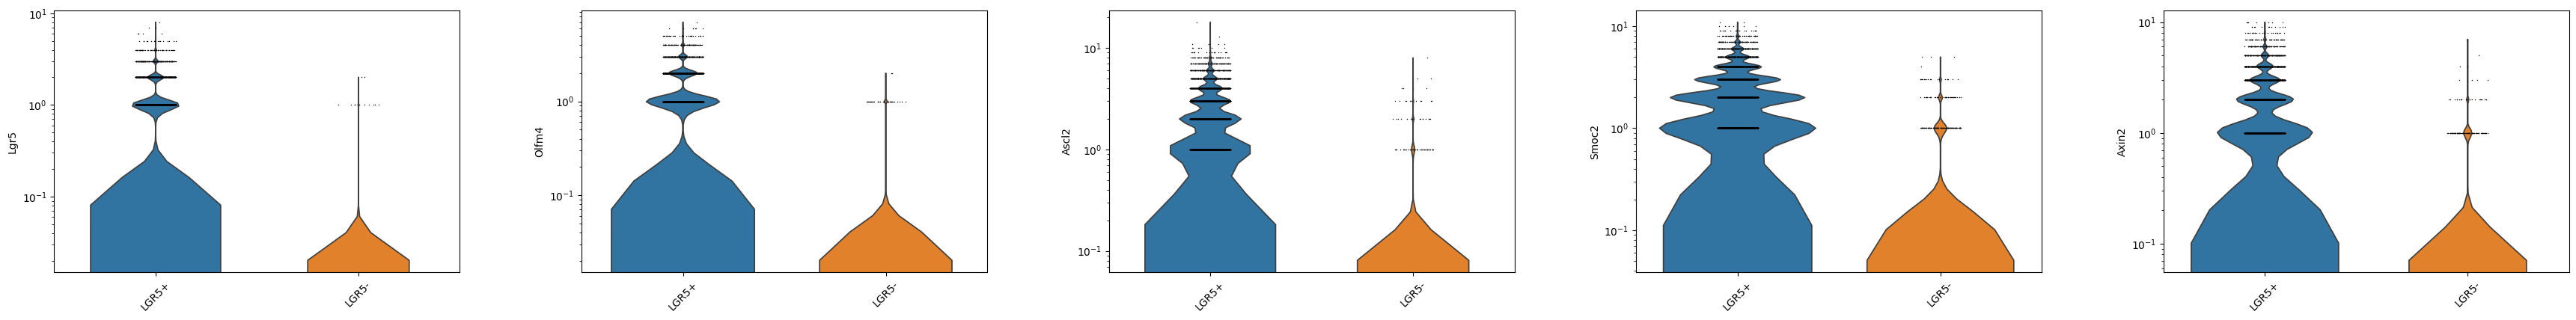

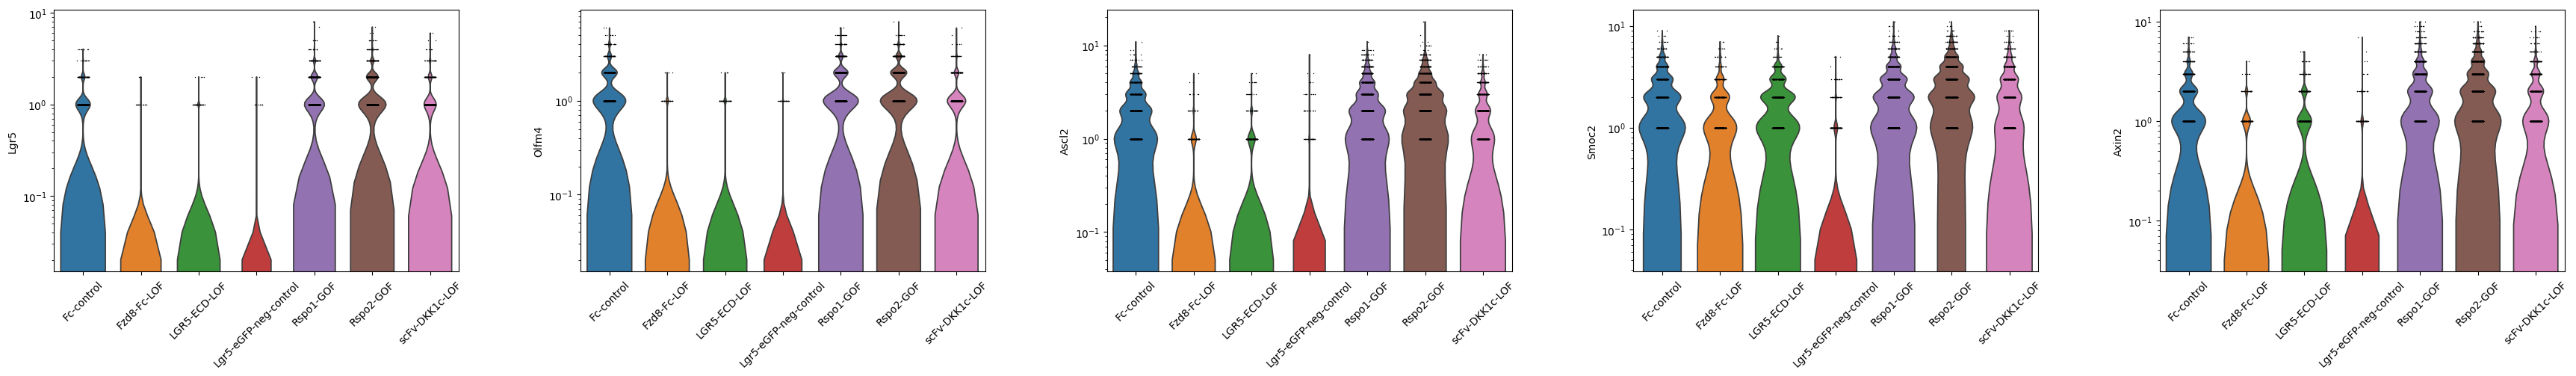

In [10]:
isc_markers = [g for g in ['Lgr5', 'Olfm4', 'Ascl2', 'Smoc2', 'Axin2'] if g in adata.var_names]
if isc_markers:
    sc.pl.violin(adata, isc_markers, groupby='lgr5_status', rotation=45, log=True)
    sc.pl.violin(adata, isc_markers, groupby='condition', rotation=45, log=True)

### Record provenance and save

In [11]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
adata.uns['GSE'] = 'GSE92865'
adata.uns['publication'] = 'Yan KS et al., Nature 545:238-242 (2017) — Non-equivalence of Wnt and R-spondin ligands during Lgr5+ ISC self-renewal'
adata.uns['genome_reference'] = 'mm10 (per GEO upload — shared GSE92865_mm10_genes.tsv across all samples)'
adata.uns['source_files'] = sorted(os.listdir(DATA_DIR)) + ['../GSE92865_mm10_genes.tsv']
adata.uns['processing_history'] = {
    timestamp: 'AnnData created from 14 GSE92865 10x mtx files with shared mm10 gene reference; concatenated inner-join (gene set is identical across samples by construction); lgr5_status/lgr5_label_raw/condition/cell_type assigned per sample; QC metrics computed; no filtering applied.',
}

out_dir = 'data/LGR5_analysis'
os.makedirs(out_dir, exist_ok=True)
out_path = f'{out_dir}/gut_mm_GSE92865_AM_{timestamp}_raw.h5ad'
adata.write_h5ad(out_path)
print(out_path, adata.shape)

data/LGR5_analysis/gut_mm_GSE92865_AM_07052026_233644_raw.h5ad (13247, 27998)
